In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torchvision.datasets.folder import ImageFolder, default_loader, IMG_EXTENSIONS 
import torchvision.models as models
from PIL import Image

from data_utils import ImageAndPathDataset

In [2]:
transform = transforms.Compose([transforms.Resize((224, 224)),
                                transforms.ToTensor()])
dataset = ImageAndPathDataset('./../MovieGenre/content/sorted_movie_posters_paligema', transform)

In [3]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)

In [5]:
ds = ImageFolder('./../MovieGenre/content/sorted_movie_posters_paligema', transform=transform, loader=default_loader)

In [6]:
ds.find_classes('./../MovieGenre/content/sorted_movie_posters_paligema')

(['action',
  'animation',
  'comedy',
  'documentary',
  'drama',
  'fantasy',
  'horror',
  'romance',
  'science Fiction',
  'thriller'],
 {'action': 0,
  'animation': 1,
  'comedy': 2,
  'documentary': 3,
  'drama': 4,
  'fantasy': 5,
  'horror': 6,
  'romance': 7,
  'science Fiction': 8,
  'thriller': 9})

In [7]:
dt = DataLoader(ds, batch_size=4, shuffle=True, num_workers=4)

In [8]:
x, y = next(iter(dt))

In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix

categories = ['action', 'animation', 'comedy', 'documentary',
                'drama', 'fantasy', 'horror', 'romance',
                'science fiction', 'thriller']

#encoder = LabelEncoder()
#encoder.fit(categories)



In [14]:
model_path = './weights/movie_net.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.mobilenet_v3_small(weights=None)
model.classifier = torch.nn.Linear(576, 10)

# Load the model
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
#model.eval()

model.to(device)


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

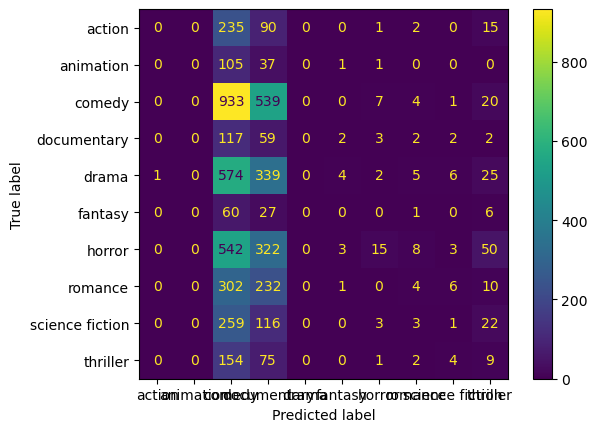

In [ ]:
# Confusion matrix
y_true = []
y_pred = []

for x, y in dt:
    x = x.to(device)
    y = y.to(device)
    y_true.extend(y.cpu().numpy())
    y_pred.extend(model(x).argmax(dim=1).cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot

## Testing the API

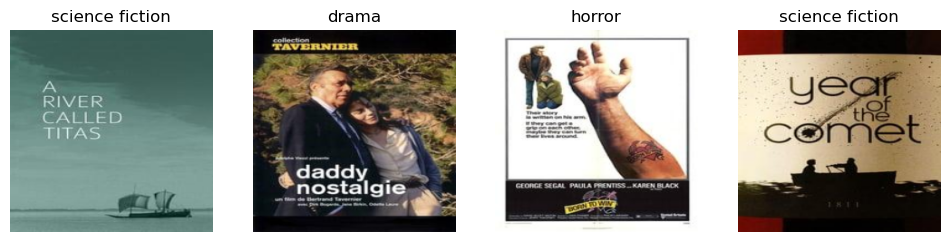

In [15]:
import matplotlib.pyplot as plt

x, y = next(iter(dt))

fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    ax[i].imshow(x[i].permute(1, 2, 0))
    ax[i].set_title(categories[y[i].item()])
    ax[i].axis('off')

In [39]:
genres_dict = {0 : 'action',1 :'animation', 2 : 'comedy', 3 : 'documentary', 
                4 : 'drama', 5 : 'fantasy', 6 : 'horror', 7 : 'romance', 
                8 : 'science Fiction',9 : 'thriller'}

In [40]:
import requests
import io

for i in range(4):
    image, label = x[i], y[i]
    label = genres_dict[label.item()]
    to_PIL = transforms.ToPILImage()
    image = to_PIL(image)
    img_binary = io.BytesIO()
    image.save(img_binary, format='PNG')
    #Send request to the API
    response = requests.post("http://127.0.0.1:5000/predict", data=img_binary.getvalue())
    print("Predicted Label:", response.json()["prediction"], "True Label:", label)

Predicted Label: action True Label: science Fiction
Predicted Label: action True Label: drama
Predicted Label: animation True Label: horror
Predicted Label: action True Label: science Fiction


In [34]:
image, label = x[0], y[0]

to_PIL = transforms.ToPILImage()
img_pil = to_PIL(image)
img_pil.show()
img_binary = io.BytesIO()
img_pil.save(img_binary, format='PNG')

imp_pil = Image.open(io.BytesIO(img_binary.getvalue()))

In [3]:
import pandas as pd

df = pd.read_csv('./../../../archive (2)/movies_metadata.csv')

/home/axel/anaconda3/envs/optim1/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3577: DtypeWarning: Columns (10) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0
